# Game conditions

## Objective

In this textbook I want to explore how specific circumstances of the matches might affect goals scored.

## Libraries

In [168]:
library(tidyverse)
library(car)
library(here)
library(ggpubr)
library(stargazer)
library(fastDummies)

## Data

In [169]:
Games <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "GamesModeling.rds"))
Weather <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "Weather.rds"))
DistancebetweenStadiums <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "DistanceTravelled.rds"))

## Functions

In [170]:
compare_poisson_models <- function(data, formulas, model_names, outcome = "goals_for",
                                   n_sims = 100, train_prop = 0.8, seed = 2026){

    set.seed(seed)

    log_loss_matrix <- matrix(
        NA,
        nrow = n_sims,
        ncol = length(formulas)
    )

    colnames(log_loss_matrix) <- model_names

    for(i in 1:n_sims){

        train_index <- sample(
            1:nrow(data),
            size = train_prop * nrow(data)
        )

        train_data <- data[train_index, ]
        test_data  <- data[-train_index, ]

        for(j in 1:length(formulas)){

            model <- glm(
                as.formula(formulas[j]),
                family = poisson,
                data = train_data
            )

            pred <- predict(
                model,
                newdata = test_data,
                type = "response"
            )

            log_loss_matrix[i, j] <- -mean(
                dpois(
                    x = test_data[[outcome]],
                    lambda = pred,
                    log = TRUE
                )
            )
        }
    }

    results <- data.frame(
        Model = model_names,
        Mean_Log_Loss = colMeans(log_loss_matrix),
        SD_Log_Loss = apply(log_loss_matrix, 2, sd)
    )

    results <- results[order(results$Mean_Log_Loss), ]

    best_model <- colnames(log_loss_matrix)[apply(log_loss_matrix, 1, which.min)]

    win_table <- data.frame(
        Model = names(table(best_model)),
        Wins = as.numeric(table(best_model))
    )

    return(
        list(
            results = results,
            wins = win_table,
            log_losses = as.data.frame(log_loss_matrix)
        )
    )
}

In [171]:
test_add_one_poisson <- function(data, base_formula, candidate_vars,
                                 outcome = "goals_for",
                                 n_sims = 100,
                                 train_prop = 0.8,
                                 seed = 2026){

    set.seed(seed)

    # Create the same train/test splits for every model
    splits <- vector("list", n_sims)

    for(i in 1:n_sims){
        splits[[i]] <- sample(
            1:nrow(data),
            size = floor(train_prop * nrow(data))
        )
    }

    # Function to calculate log loss for one formula
    get_log_losses <- function(formula_string){

        log_losses <- c()

        for(i in 1:n_sims){

            train_index <- splits[[i]]

            train_data <- data[train_index, ]
            test_data  <- data[-train_index, ]

            model <- glm(
                as.formula(formula_string),
                family = poisson,
                data = train_data
            )

            pred <- predict(
                model,
                newdata = test_data,
                type = "response"
            )

            log_losses[i] <- -mean(
                dpois(
                    x = test_data[[outcome]],
                    lambda = pred,
                    log = TRUE
                )
            )
        }

        return(log_losses)
    }

    # Base model
    base_log_losses <- get_log_losses(base_formula)

    results <- data.frame(
        Variable = "CURRENT BASE",
        Formula = base_formula,
        Mean_Log_Loss = mean(base_log_losses),
        SD_Log_Loss = sd(base_log_losses),
        Improvement_vs_Base = 0,
        Wins_vs_Base = NA
    )

    # Candidate variables
    for(var in candidate_vars){

        formula_string <- paste(
            base_formula,
            "+",
            var
        )

        log_losses <- get_log_losses(formula_string)

        results <- rbind(
            results,
            data.frame(
                Variable = var,
                Formula = formula_string,
                Mean_Log_Loss = mean(log_losses),
                SD_Log_Loss = sd(log_losses),
                Improvement_vs_Base = mean(base_log_losses) - mean(log_losses),
                Wins_vs_Base = sum(log_losses < base_log_losses)
            )
        )
    }

    results <- results[order(results$Mean_Log_Loss), ]

    return(results)
}

In [172]:
forward_select_poisson <- function(data, base_formula, candidate_vars,
                                   outcome = "goals_for",
                                   n_sims = 100,
                                   train_prop = 0.8,
                                   seed = 2026,
                                   min_improvement = 0){

    set.seed(seed)

    # Create fixed train/test splits
    splits <- vector("list", n_sims)

    for(i in 1:n_sims){
        splits[[i]] <- sample(
            1:nrow(data),
            size = floor(train_prop * nrow(data))
        )
    }

    # Function to calculate log losses for one formula
    get_log_losses <- function(formula_string){

        log_losses <- c()

        for(i in 1:n_sims){

            train_index <- splits[[i]]

            train_data <- data[train_index, ]
            test_data  <- data[-train_index, ]

            model <- glm(
                as.formula(formula_string),
                family = poisson,
                data = train_data
            )

            pred <- predict(
                model,
                newdata = test_data,
                type = "response"
            )

            log_losses[i] <- -mean(
                dpois(
                    x = test_data[[outcome]],
                    lambda = pred,
                    log = TRUE
                )
            )
        }

        return(log_losses)
    }

    selected_vars <- c()
    remaining_vars <- candidate_vars
    current_formula <- base_formula
    current_log_losses <- get_log_losses(current_formula)
    current_mean_log_loss <- mean(current_log_losses)

    selection_history <- data.frame(
        Step = 0,
        Added_Variable = "BASE MODEL",
        Formula = current_formula,
        Mean_Log_Loss = current_mean_log_loss,
        Improvement = 0,
        Wins_vs_Previous = NA
    )

    step <- 1

    while(length(remaining_vars) > 0){

        step_results <- data.frame()

        for(var in remaining_vars){

            test_formula <- paste(
                current_formula,
                "+",
                var
            )

            test_log_losses <- get_log_losses(test_formula)

            step_results <- rbind(
                step_results,
                data.frame(
                    Variable = var,
                    Formula = test_formula,
                    Mean_Log_Loss = mean(test_log_losses),
                    Improvement = current_mean_log_loss - mean(test_log_losses),
                    Wins_vs_Current = sum(test_log_losses < current_log_losses)
                )
            )
        }

        step_results <- step_results[order(step_results$Mean_Log_Loss), ]

        best_var <- step_results$Variable[1]
        best_formula <- step_results$Formula[1]
        best_mean_log_loss <- step_results$Mean_Log_Loss[1]
        best_improvement <- step_results$Improvement[1]
        best_wins <- step_results$Wins_vs_Current[1]

        if(best_improvement <= min_improvement){
            break
        }

        selected_vars <- c(selected_vars, best_var)
        remaining_vars <- setdiff(remaining_vars, best_var)

        current_formula <- best_formula
        current_log_losses <- get_log_losses(current_formula)
        current_mean_log_loss <- best_mean_log_loss

        selection_history <- rbind(
            selection_history,
            data.frame(
                Step = step,
                Added_Variable = best_var,
                Formula = current_formula,
                Mean_Log_Loss = current_mean_log_loss,
                Improvement = best_improvement,
                Wins_vs_Previous = best_wins
            )
        )

        step <- step + 1
    }

    return(
        list(
            selected_vars = selected_vars,
            final_formula = current_formula,
            selection_history = selection_history,
            remaining_vars = remaining_vars
        )
    )
}

## Rest

`geom_smooth()` using formula = 'y ~ x'


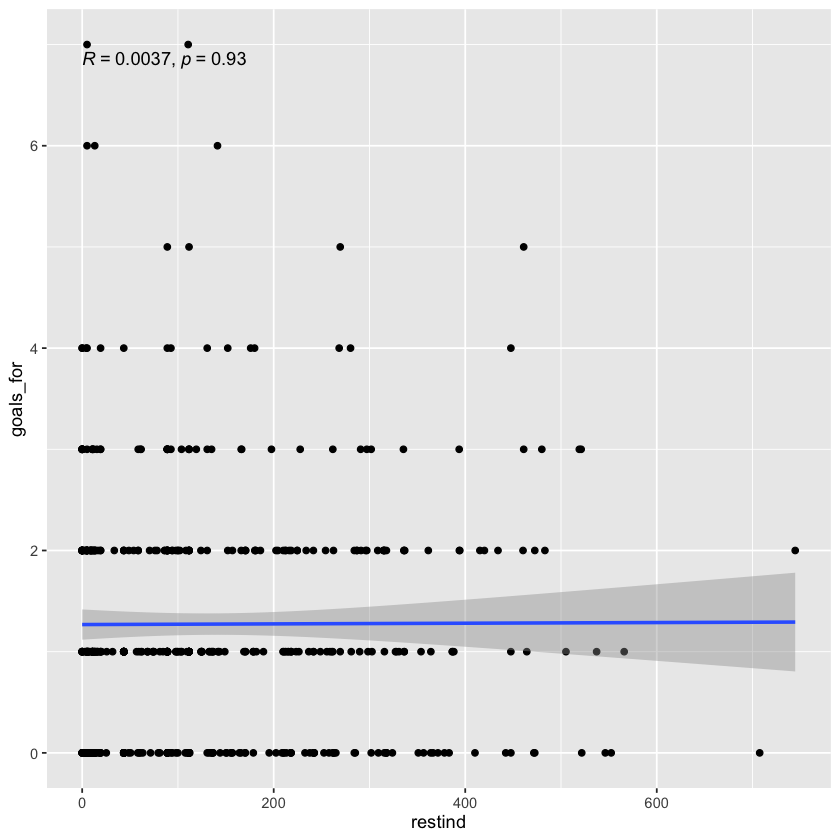

In [173]:
Games <- left_join(Games, DistancebetweenStadiums, by= c("match_id", "team_id"))

Games %>% 
    mutate(restind= (distance_traveled_km/rest_days)) %>%
        ggplot(aes(x=restind, y=goals_for)) +
             geom_point() +
                geom_smooth(method="lm", se = TRUE) +
                      stat_cor()

`geom_smooth()` using formula = 'y ~ x'


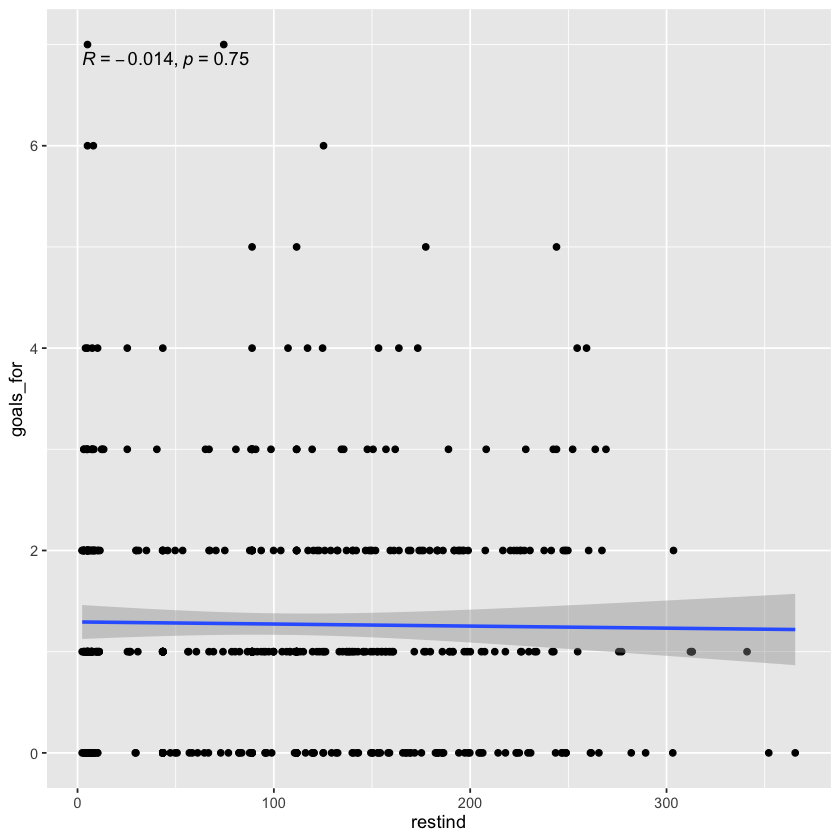

In [174]:
Games %>% 
    mutate(restind= (distance_accumulated_km/rest_accumulated)) %>%
        ggplot(aes(x=restind, y=goals_for)) +
             geom_point() +
                geom_smooth(method="lm", se = TRUE) +
                      stat_cor()

In [175]:
base <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2), family=poisson, Games)
m1 <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2) + distance_traveled_km/rest_days, family=poisson, Games)
m2 <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2) + distance_accumulated_km/rest_accumulated, family=poisson, Games)

stargazer( base, m1, m2, type="text")



                                              Dependent variable:     
                                         -----------------------------
                                                   goals_for          
                                            (1)       (2)       (3)   
----------------------------------------------------------------------
I(team_ELO - opponent_ELO)               0.002***  0.002***  0.002*** 
                                         (0.0002)  (0.0002)  (0.0002) 
                                                                      
opp_prior_world_cups_coached              0.078*    0.079*    0.076*  
                                          (0.044)   (0.044)   (0.044) 
                                                                      
opp_players_with_multiple_prior_wcs       0.037*    0.038*    0.037*  
                                          (0.021)   (0.021)   (0.021) 
                                                                      
I(avg

In [176]:
BIC(base)
BIC(m1)
BIC(m2)

[1] 1471.852

[1] 1484.01

[1] 1484.12

Estimates are not statistically relevant and BIC goes up significantly when adding any of this metrics. I will run a forward selection just in case that interactions are the problem but this variables are most likely not useful.

In [177]:
base_formula <- paste(
    "goals_for ~ I(team_ELO - opponent_ELO)",
    "+ opp_prior_world_cups_coached",
    "+ opp_players_with_multiple_prior_wcs",
    "+ I(avg_age^2)",
    "+ opp_avg_age",
    "+ I(opp_avg_age^2)"
)

candidate_vars <- c(
    "I(distance_traveled_km / rest_days)",
    "distance_accumulated_km",
    "rest_accumulated"
)

forward_distance_rest <- forward_select_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars,
    min_improvement = 0
)

forward_distance_rest$selection_history
forward_distance_rest$final_formula
forward_distance_rest$selected_vars

Step,Added_Variable,Formula,Mean_Log_Loss,Improvement,Wins_vs_Previous
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<lgl>
0,BASE MODEL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2),1.410453,0,NA


[1] "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2)"

NULL

As expected no improvement.

## Weather

In [178]:
Weather <- Weather %>%
    select(match_id, temperature_2m, wind_speed_10m, precipitation) %>%
    distinct(match_id, .keep_all = TRUE)

Games <- left_join(Games, Weather, by = "match_id")

Let's run a forward selection with our three weather variables.

In [179]:
base_formula <- paste(
    "goals_for ~ I(team_ELO - opponent_ELO)",
    "+ opp_prior_world_cups_coached",
    "+ opp_players_with_multiple_prior_wcs",
    "+ I(avg_age^2)",
    "+ opp_avg_age",
    "+ I(opp_avg_age^2)"
)

candidate_vars <- c(
    "temperature_2m",
    "wind_speed_10m",
    "precipitation"
)

forward_weather <- forward_select_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars,
    min_improvement = 0
)

forward_weather$selection_history
forward_weather$final_formula
forward_weather$selected_vars

Step,Added_Variable,Formula,Mean_Log_Loss,Improvement,Wins_vs_Previous
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<lgl>
0,BASE MODEL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2),1.410453,0,NA


[1] "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2)"

NULL

Again, no relevant effects. I expected this because the data is not very high quality. I obtained coordinates based on cities, not stadiums. cities may be huge and have slightly different weather conditions in different areas.

## Tournament stage

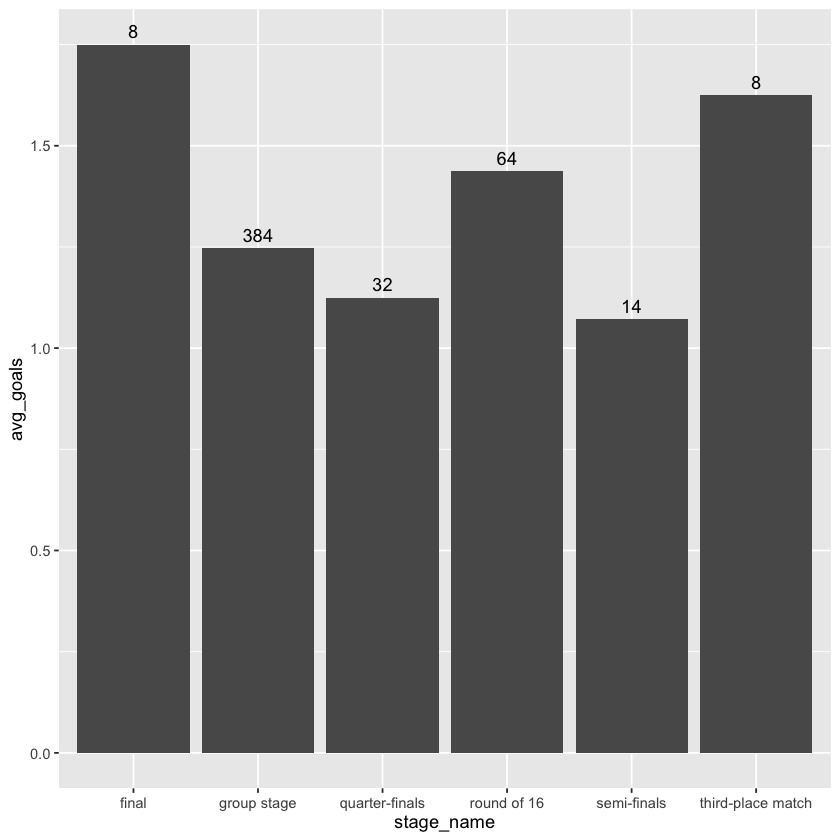

In [180]:
Games %>%
    group_by(stage_name) %>%
    summarize(
        avg_goals = mean(goals_for),
        n = n()
    ) %>%
    ggplot(aes(stage_name, avg_goals)) +
    geom_col() +
    geom_text(aes(label = n), vjust = -0.5)

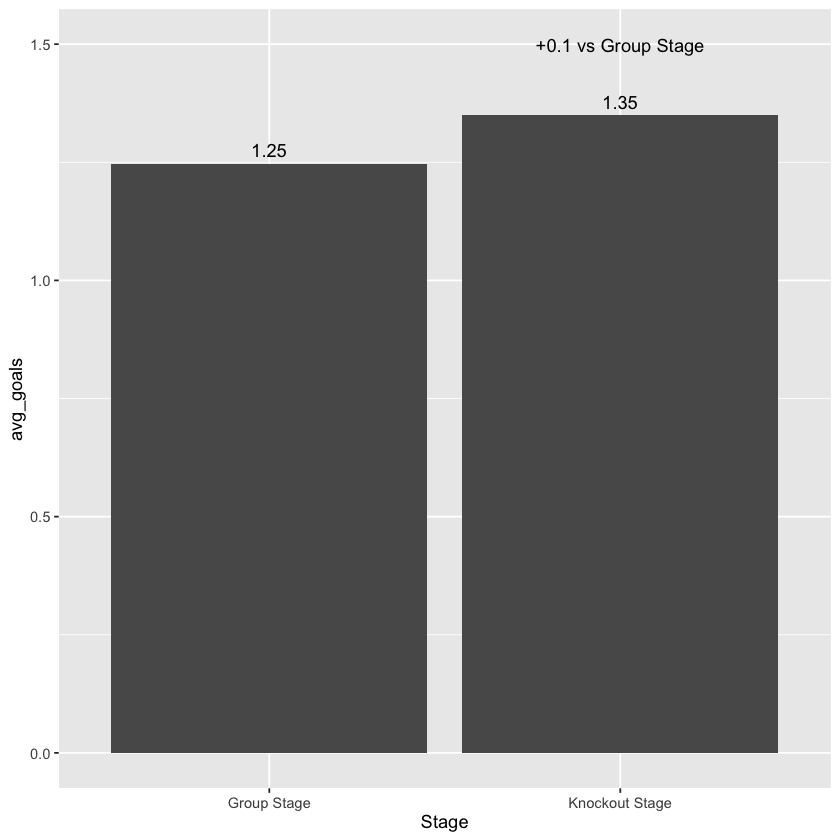

In [181]:
plot_data <- Games %>%
    mutate(
        Stage = ifelse(group_stage == 1,
                       "Group Stage",
                       "Knockout Stage")
    ) %>%
    group_by(Stage) %>%
    summarize(
        avg_goals = mean(goals_for, na.rm = TRUE)
    )

ggplot(plot_data, aes(x = Stage, y = avg_goals)) +
    geom_col() +
    geom_text(
        aes(
            label = round(avg_goals, 2)
        ),
        vjust = -0.5
    ) +
    annotate(
        "text",
        x = 2,
        y = plot_data$avg_goals[2] + 0.15,
        label = paste0(
            "+",
            round(
                plot_data$avg_goals[2] -
                plot_data$avg_goals[1],
                2
            ),
            " vs Group Stage"
        )
    )


Let's see if this difference is already accounted by our other explanatory variables or does group stage vs knockout is good extra explanatory information.

In [182]:
base <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2), family=poisson, Games) 
m1 <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2)+group_stage, family=poisson, Games)

BIC(base)
BIC(m1)

[1] 1471.852

[1] 1477.359

In [183]:
stargazer(base,m1, type="text", report="pvc")


                                        Dependent variable:     
                                    ----------------------------
                                             goals_for          
                                         (1)            (2)     
----------------------------------------------------------------
                                      p = 0.000      p = 0.000  
I(team_ELO - opponent_ELO)              0.002          0.002    
                                                                
                                      p = 0.076      p = 0.070  
opp_prior_world_cups_coached            0.078          0.080    
                                                                
                                      p = 0.074      p = 0.085  
opp_players_with_multiple_prior_wcs     0.037          0.036    
                                                                
                                      p = 0.007      p = 0.009  
I(avg_age2)             

In [184]:
base_formula <- paste(
    "goals_for ~ I(team_ELO - opponent_ELO)",
    "+ opp_prior_world_cups_coached",
    "+ opp_players_with_multiple_prior_wcs",
    "+ I(avg_age^2)",
    "+ opp_avg_age",
    "+ I(opp_avg_age^2)"
)

candidate_vars <- c(
    "group_stage",
    "group_stage*I(team_ELO-opponent_ELO)"
)

forward_weather <- forward_select_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars,
    min_improvement = 0
)

forward_weather$selection_history
forward_weather$final_formula
forward_weather$selected_vars

Step,Added_Variable,Formula,Mean_Log_Loss,Improvement,Wins_vs_Previous
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<lgl>
0,BASE MODEL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2),1.410453,0,NA


[1] "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2)"

NULL

It seems like this difference in average gaols is already accounted for.

## Editions

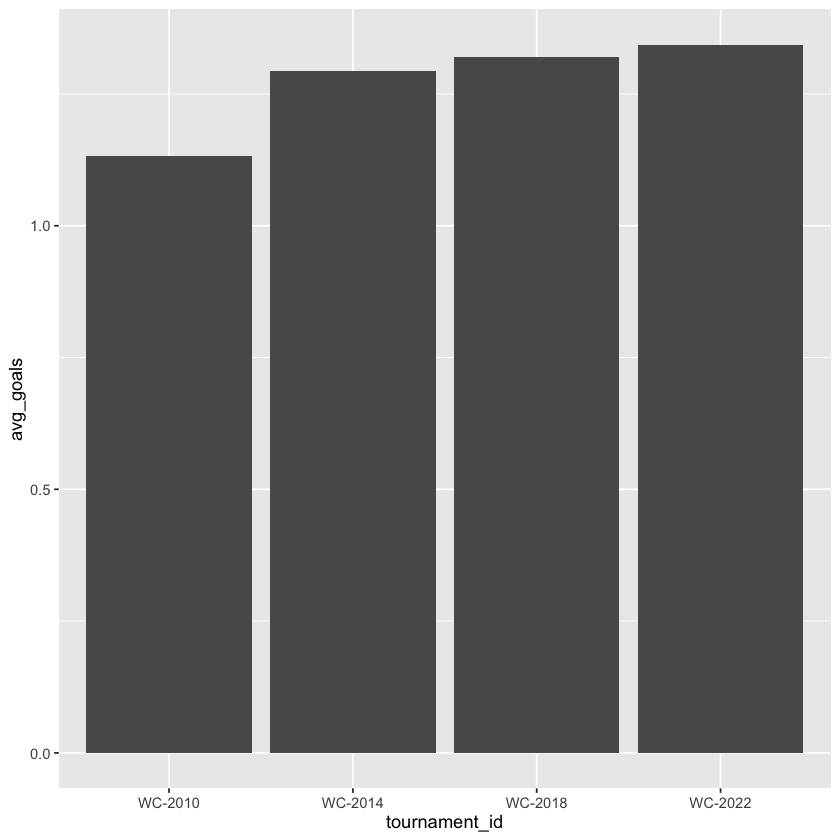

In [185]:
Games %>%
    group_by(tournament_id) %>%
    summarize(avg_goals = mean(goals_for, na.rm = TRUE)) %>%
    ggplot(aes(x = tournament_id, y = avg_goals)) +
    geom_col()

It seems that goals have increased every world cup. Let's check if this is alreayd accounted for.

In [186]:
Games <- Games %>%
    mutate(
        wc_number = case_when(
            tournament_id == "WC-2010" ~ 0,
            tournament_id == "WC-2014" ~ 1,
            tournament_id == "WC-2018" ~ 2,
            tournament_id == "WC-2022" ~ 3,
            TRUE ~ NA_real_
        ),

        SouthAfrica = ifelse(
            tournament_id == "WC-2010",
            1,
            0
        )
    )

In [187]:
base_formula <- paste(
    "goals_for ~ I(team_ELO - opponent_ELO)",
    "+ opp_prior_world_cups_coached",
    "+ opp_players_with_multiple_prior_wcs",
    "+ I(avg_age^2)",
    "+ opp_avg_age",
    "+ I(opp_avg_age^2)"
)

candidate_vars <- c(
    "wc_number",
    "I(wc_number^2)",
    "I(log1p(wc_number))",
    "SouthAfrica"
)

forward_weather <- forward_select_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars,
    min_improvement = 0
)

forward_weather$selection_history
forward_weather$final_formula
forward_weather$selected_vars

Step,Added_Variable,Formula,Mean_Log_Loss,Improvement,Wins_vs_Previous
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>
0,BASE MODEL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2),1.410453,0.000000000,NA
1,SouthAfrica,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + SouthAfrica,1.408572,0.001880487,79


[1] "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + SouthAfrica"

[1] "SouthAfrica"

It seems reasonable to add a dummy variable for the south african world cup since goal scoring was very much lower. this might be a proxy for a few things.
- Stoppage time increasing significantly
- Change in tactics
- Wc 2010 was played in winter Weather

## Distance from home country

`geom_smooth()` using formula = 'y ~ x'


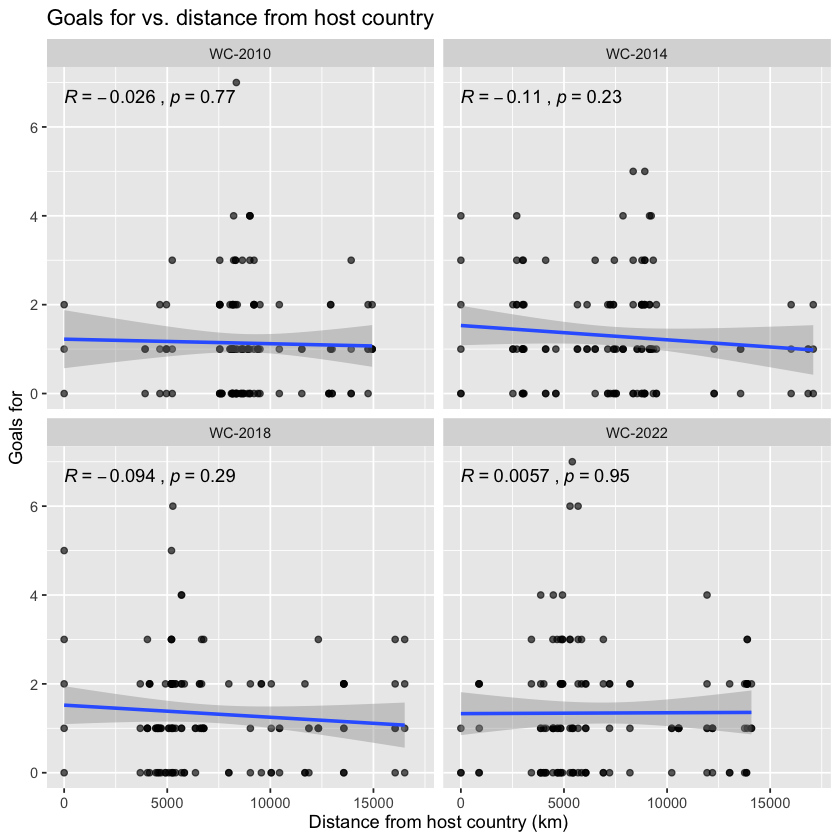

In [188]:
DistanceFromHome <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "DistanceFromHome.rds"))

Games <- Games %>%
    left_join(
        DistanceFromHome %>%
            select(tournament_id, team_id, distance_from_host_km),
        by = c("tournament_id", "team_id")
    ) %>%
    filter(tournament_id != "WC-2026")

Games %>%
    ggplot(aes(x = distance_from_host_km, y = goals_for)) +
        geom_point(alpha = 0.65) +
        geom_smooth(method = "lm", se = TRUE) +
        stat_cor(aes(label = paste(after_stat(r.label), after_stat(p.label), sep = "~`,`~"))) +
        facet_wrap(~ tournament_id) +
        labs(
            x = "Distance from host country (km)",
            y = "Goals for",
            title = "Goals for vs. distance from host country"
        )

There seems to be a differing effect per world cup. My first assumption is that this is caused by proximity to usual footbaling power houses. We see stronger relations between distance and goals for Brazil and Russia both in zones with high foorballistic power and tradition (South America and Europe). Let's see how this holds in our model that already takes this into account

In [189]:
base_formula <- paste(
    "goals_for ~ I(team_ELO - opponent_ELO)",
    "+ opp_prior_world_cups_coached",
    "+ opp_players_with_multiple_prior_wcs",
    "+ I(avg_age^2)",
    "+ opp_avg_age",
    "+ I(opp_avg_age^2)",
    "+ SouthAfrica"
)

candidate_vars <- c(
    "distance_from_host_km",
    "log1p(distance_from_host_km)",
    "I(distance_from_host_km^2)"
)

forward_weather <- forward_select_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars,
    min_improvement = 0
)

forward_weather$selection_history
forward_weather$final_formula
forward_weather$selected_vars

Step,Added_Variable,Formula,Mean_Log_Loss,Improvement,Wins_vs_Previous
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>
0,BASE MODEL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + SouthAfrica,1.408572,0.000000000,NA
1,distance_from_host_km,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + SouthAfrica + distance_from_host_km,1.406915,0.001657047,69


[1] "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + SouthAfrica + distance_from_host_km"

[1] "distance_from_host_km"

There seems to be evidence of a relation, lets investigate further.

In [190]:
base <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2) + SouthAfrica, family=poisson, Games) 
m1 <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2) + SouthAfrica + distance_from_host_km, family=poisson, Games) 

stargazer(base, m1, type="text", report="vcp")


                                        Dependent variable:     
                                    ----------------------------
                                             goals_for          
                                         (1)            (2)     
----------------------------------------------------------------
I(team_ELO - opponent_ELO)              0.002          0.002    
                                      p = 0.000      p = 0.000  
                                                                
opp_prior_world_cups_coached            0.083          0.082    
                                      p = 0.063      p = 0.065  
                                                                
opp_players_with_multiple_prior_wcs     0.031          0.030    
                                      p = 0.132      p = 0.151  
                                                                
I(avg_age2)                             -0.002        -0.002    
                        

This results suggest that the difference in goals in SouthAfrica is explained to some extent by countries being further away. Lets epxlore this further.

In [191]:
m2 <- glm(goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2) + distance_from_host_km, family=poisson, Games) 


stargazer(base, m1, m2, type="text", report="vcp")


                                         Dependent variable:     
                                    -----------------------------
                                              goals_for          
                                       (1)       (2)       (3)   
-----------------------------------------------------------------
I(team_ELO - opponent_ELO)            0.002     0.002     0.002  
                                    p = 0.000 p = 0.000 p = 0.000
                                                                 
opp_prior_world_cups_coached          0.083     0.082     0.078  
                                    p = 0.063 p = 0.065 p = 0.074
                                                                 
opp_players_with_multiple_prior_wcs   0.031     0.030     0.034  
                                    p = 0.132 p = 0.151 p = 0.101
                                                                 
I(avg_age2)                          -0.002    -0.002    -0.002  
         

In [192]:
model_test <- compare_poisson_models(
    data = Games,
    formulas = c(
        "goals_for ~ I(team_ELO - opponent_ELO) +
            opp_prior_world_cups_coached +
            opp_players_with_multiple_prior_wcs +
            I(avg_age^2) +
            opp_avg_age +
            I(opp_avg_age^2) +
            SouthAfrica",

        "goals_for ~ I(team_ELO - opponent_ELO) +
            opp_prior_world_cups_coached +
            opp_players_with_multiple_prior_wcs +
            I(avg_age^2) +
            opp_avg_age +
            I(opp_avg_age^2) +
            SouthAfrica +
            distance_from_host_km",

        "goals_for ~ I(team_ELO - opponent_ELO) +
            opp_prior_world_cups_coached +
            opp_players_with_multiple_prior_wcs +
            I(avg_age^2) +
            opp_avg_age +
            I(opp_avg_age^2) +
            distance_from_host_km"
    ),
    model_names = c(
        "SouthAfrica",
        "SouthAfrica + Distance",
        "Distance"
    )
)

model_test$results
model_test$wins

,Model,Mean_Log_Loss,SD_Log_Loss
,<chr>,<dbl>,<dbl>
SouthAfrica + Distance,SouthAfrica + Distance,1.406915,0.05929225
Distance,Distance,1.407290,0.05945056
SouthAfrica,SouthAfrica,1.408572,0.06072168


Model,Wins
<chr>,<dbl>
Distance,26
SouthAfrica,26
SouthAfrica + Distance,48


In [193]:
BIC(base)
BIC(m1)
BIC(m2)

[1] 1475.276

[1] 1478.728

[1] 1474.275

I feel comfortable only keeping distance from host.

## Conferences

In [194]:
confederations <- worldcup::teams %>%
    select(team_id, confederation_code)

confederations <- dummy_cols(
    confederations,
    select_columns = "confederation_code"
) %>%
    select(-confederation_code) %>%
     rename(
        AFC = confederation_code_AFC,
        CAF = confederation_code_CAF,
        CONCACAF = confederation_code_CONCACAF,
        CONMEBOL = confederation_code_CONMEBOL,
        OFC = confederation_code_OFC,
        UEFA = confederation_code_UEFA
    )

head(confederations)


team_id,AFC,CAF,CONCACAF,CONMEBOL,OFC,UEFA
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
T-01,0,1,0,0,0,0
T-02,0,1,0,0,0,0
T-03,0,0,0,1,0,0
T-04,1,0,0,0,0,0
T-05,0,0,0,0,0,1
T-06,0,0,0,0,0,1


In [195]:

Games <- left_join(Games, confederations, by = "team_id")

base_formula <- paste(
    "goals_for ~ I(team_ELO - opponent_ELO)",
    "+ opp_prior_world_cups_coached",
    "+ opp_players_with_multiple_prior_wcs",
    "+ I(avg_age^2)",
    "+ opp_avg_age",
    "+ I(opp_avg_age^2)",
    "+ distance_from_host_km"
)

candidate_vars <- c(
    "AFC",
    "CAF",
    "CONCACAF",
    "CONMEBOL",
    "OFC",
    "UEFA",
    "AFC:I(team_ELO - opponent_ELO)",
    "CAF:I(team_ELO - opponent_ELO)",
    "CONCACAF:I(team_ELO - opponent_ELO)",
    "CONMEBOL:I(team_ELO - opponent_ELO)",
    "OFC:I(team_ELO - opponent_ELO)",
    "UEFA:I(team_ELO - opponent_ELO)"
)

forward_distance_rest <- forward_select_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars,
    min_improvement = 0
)

forward_distance_rest$selection_history
forward_distance_rest$final_formula
forward_distance_rest$selected_vars


Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"


Step,Added_Variable,Formula,Mean_Log_Loss,Improvement,Wins_vs_Previous
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<lgl>
0,BASE MODEL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + distance_from_host_km,1.40729,0,NA


[1] "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs + I(avg_age^2) + opp_avg_age + I(opp_avg_age^2) + distance_from_host_km"

NULL

In [196]:
base_formula <- "goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km"

candidate_vars <- c(
     "AFC",
    "CAF",
    "CONCACAF",
    "CONMEBOL",
    "OFC",
    "UEFA",
    "AFC:I(team_ELO - opponent_ELO)",
    "CAF:I(team_ELO - opponent_ELO)",
    "CONCACAF:I(team_ELO - opponent_ELO)",
    "CONMEBOL:I(team_ELO - opponent_ELO)",
    "OFC:I(team_ELO - opponent_ELO)",
    "UEFA:I(team_ELO - opponent_ELO)"
)

test_add_one_poisson(
    data = Games,
    base_formula = base_formula,
    candidate_vars = candidate_vars
)

Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
"prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases"


,Variable,Formula,Mean_Log_Loss,SD_Log_Loss,Improvement_vs_Base,Wins_vs_Base
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
1,CURRENT BASE,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km,1.408606,0.06046427,0.0000000000,NA
4,CONCACAF,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + CONCACAF,1.408785,0.06052230,-0.0001790311,58
8,AFC:I(team_ELO - opponent_ELO),goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + AFC:I(team_ELO - opponent_ELO),1.409374,0.06084942,-0.0007678781,57
2,AFC,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + AFC,1.409700,0.06075159,-0.0010946902,44
10,CONCACAF:I(team_ELO - opponent_ELO),goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + CONCACAF:I(team_ELO - opponent_ELO),1.409748,0.06129561,-0.0011428005,54
3,CAF,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + CAF,1.410159,0.06035004,-0.0015533218,10
7,UEFA,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + UEFA,1.410236,0.06062747,-0.0016305876,17
5,CONMEBOL,goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + CONMEBOL,1.410330,0.06120650,-0.0017245288,48
11,CONMEBOL:I(team_ELO - opponent_ELO),goals_for ~ I(team_ELO - opponent_ELO) + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km + CONMEBOL:I(team_ELO - opponent_ELO),1.410647,0.06133366,-0.0020409962,44


None of this variables improve our model, this suggests that whatever effect a teams conference has on its goalscoring in the world cup is already taken into account by our model.

### - Final working model by the end of this notebook: **goals_for ~ ELO_diff + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+(avg_age^2)+opp_avg_age+(opp_avg_age^2) + distance_from_host_km**
### - BIC = **1474.27526865624**
### - Out of Sample log loss = **1.407290**

